In [101]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from matplotlib.ticker import PercentFormatter
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [102]:
df = pd.read_csv('data/gym_churn_us.csv')

Para este dataset, se ha usado notación binaria en algunas columnas, donde 0 representa "no" y 1 representa "si"

In [103]:
df.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [104]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float64
 12  Avg

In [105]:
df.columns

Index(['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone',
       'Contract_period', 'Group_visits', 'Age',
       'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime',
       'Avg_class_frequency_total', 'Avg_class_frequency_current_month',
       'Churn'],
      dtype='str')

In [106]:
len(df)

4000

In [107]:
df.nunique()

gender                                  2
Near_Location                           2
Partner                                 2
Promo_friends                           2
Phone                                   2
Contract_period                         3
Group_visits                            2
Age                                    23
Avg_additional_charges_total         4000
Month_to_end_contract                  12
Lifetime                               29
Avg_class_frequency_total            3913
Avg_class_frequency_current_month    3820
Churn                                   2
dtype: int64

In [108]:
df_dividido = pd.get_dummies(df)

In [109]:
caida_frecuencia = df['Avg_class_frequency_total'] - df['Avg_class_frequency_current_month']
df_dividido['caida_frecuencia'] = caida_frecuencia

In [110]:
df_dividido

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn,caida_frecuencia
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0,0.020398
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0,0.012693
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0,0.122596
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0,-0.151582
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0,-0.006194
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,12,0,33,2.406023,12.0,8,2.284497,2.349070,0,-0.064572
3996,0,1,0,0,1,1,1,29,68.883764,1.0,1,1.277168,0.292859,1,0.984309
3997,1,1,1,1,1,12,0,28,78.250542,11.0,2,2.786146,2.831439,0,-0.045293
3998,0,1,1,1,1,6,0,32,61.912657,5.0,3,1.630108,1.596237,0,0.033872


In [111]:
correlacion = df_dividido.corr()

Text(0.5, 1.0, 'Matriz de Correlación')

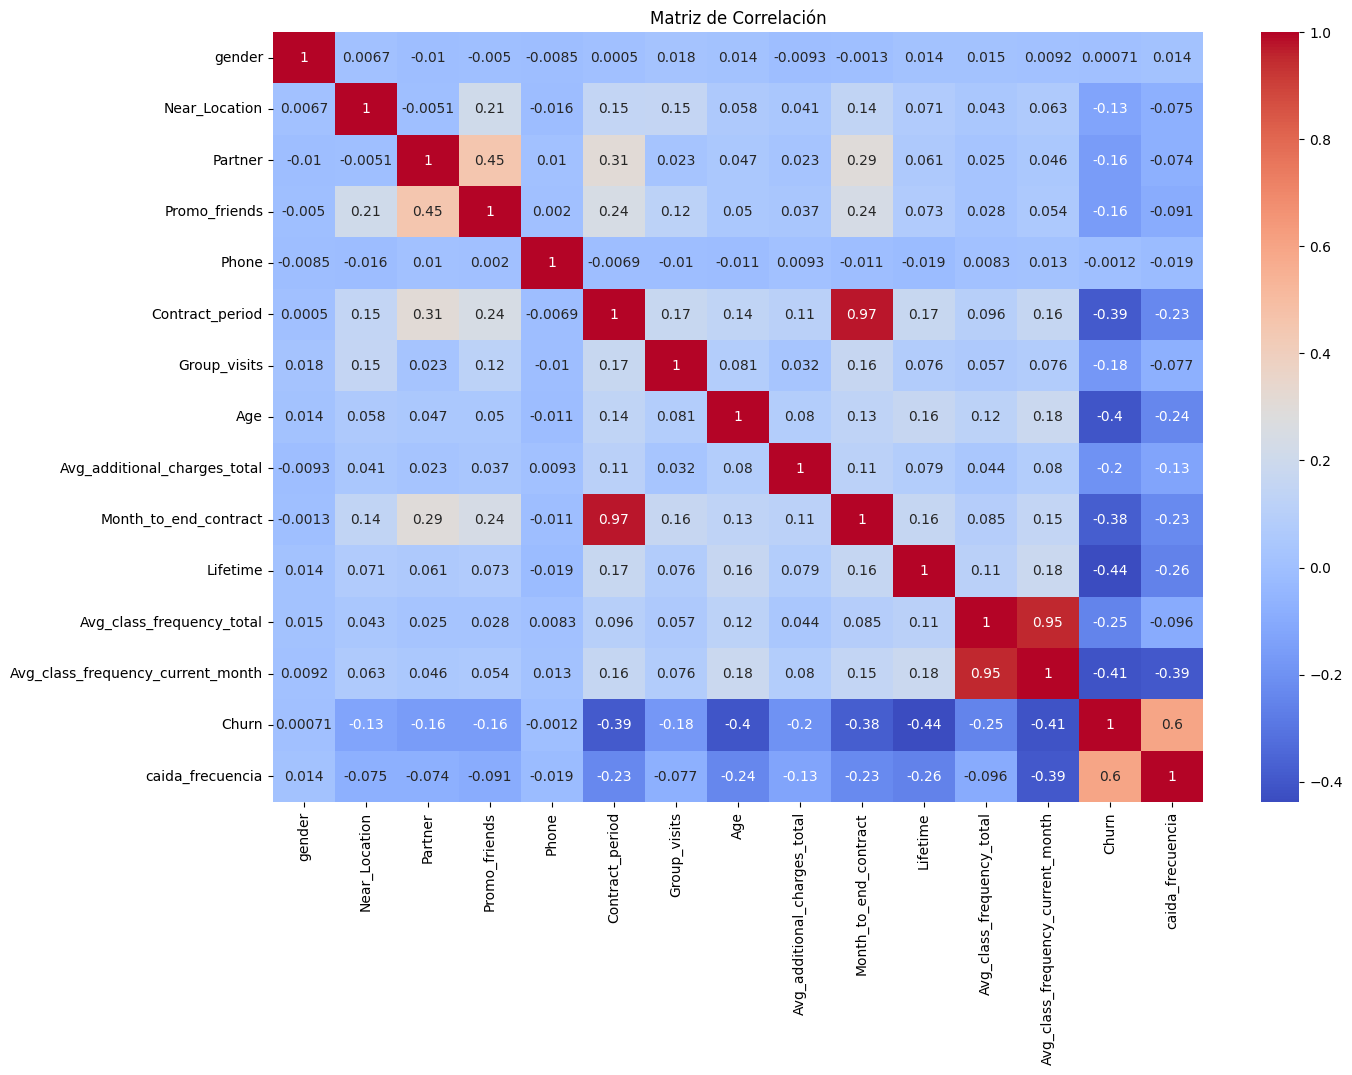

In [112]:
plt.figure(figsize=(15, 10))
sns.heatmap(correlacion, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')

In [113]:
df2 = df.copy()

In [114]:
df2.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [115]:
drop_columns = ['gender', 'Phone']

In [116]:
df2.drop(columns=drop_columns, inplace=True)

In [117]:
df2.head()

,Near_Location,Partner,Promo_friends,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,1,0,0,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,1,1,0,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


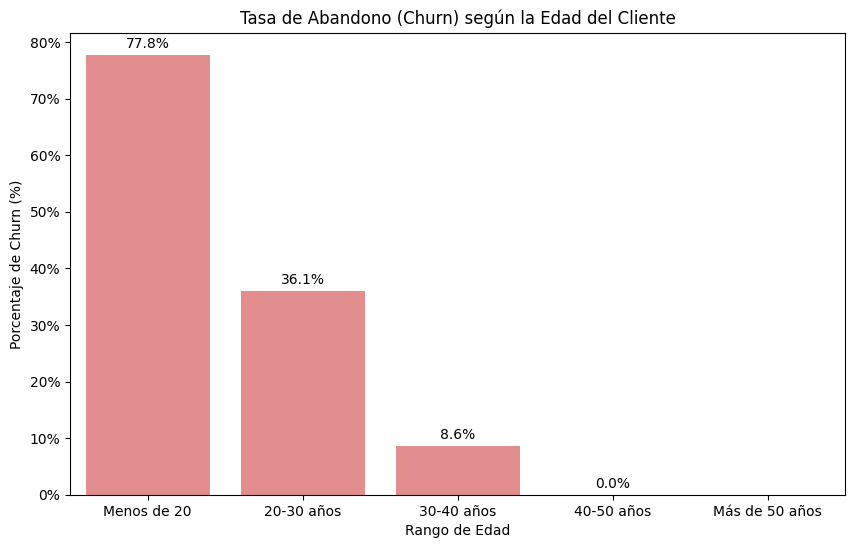

In [118]:
limites_edad = [0, 20, 30, 40, 50, 100] 

nombres_edades = ['Menos de 20', '20-30 años', '30-40 años', '40-50 años', 'Más de 50 años']

df2['Age_group'] = pd.cut(df2['Age'], bins=limites_edad, labels=nombres_edades)

plt.figure(figsize=(10, 6)) 
ax = sns.barplot(data=df2, x='Age_group', y='Churn', errorbar=None, color='lightcoral') 

ax.yaxis.set_major_formatter(PercentFormatter(1.0))

etiquetas_barras = [f"{barra.get_height():.1%}" for barra in ax.containers[0]]
ax.bar_label(ax.containers[0], labels=etiquetas_barras, padding=3)

plt.title('Tasa de Abandono (Churn) según la Edad del Cliente')
plt.ylabel('Porcentaje de Churn (%)')
plt.xlabel('Rango de Edad')

plt.show()

Las personas más jóvenes son más propensos a abandonar el gimnasio

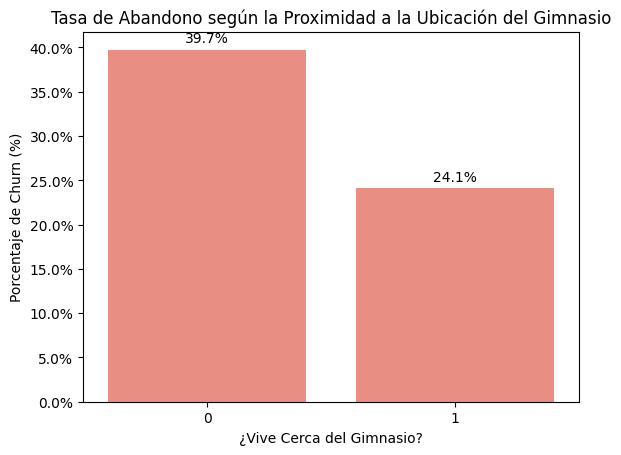

In [119]:
ax = sns.barplot(data = df2, x='Near_Location', y='Churn', errorbar=None, color='salmon')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
etiquetas_barras = [f"{barra.get_height():.1%}" for barra in ax.containers[0]]
ax.bar_label(ax.containers[0], labels=etiquetas_barras, padding=3)
plt.title('Tasa de Abandono según la Proximidad a la Ubicación del Gimnasio')
plt.ylabel('Porcentaje de Churn (%)')
plt.xlabel('¿Vive Cerca del Gimnasio?')
plt.show()

Casi el 40% de los que viven lejos del gimnasio abandonan el servicio.

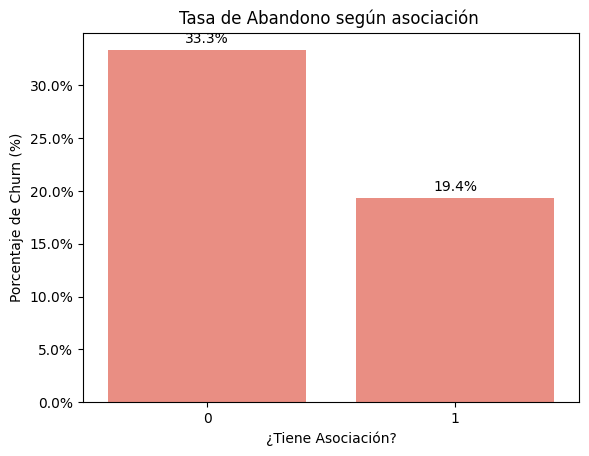

In [120]:
ax = sns.barplot(data = df2, x='Partner', y='Churn', errorbar=None, color='salmon')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
etiquetas_barras = [f"{barra.get_height():.1%}" for barra in ax.containers[0]]
ax.bar_label(ax.containers[0], labels=etiquetas_barras, padding=3)
plt.title('Tasa de Abandono según asociación ')
plt.ylabel('Porcentaje de Churn (%)')
plt.xlabel('¿Tiene Asociación?')
plt.show()

El 33% de los que abandonan el gimnasio, en su trabajo no tienen asociación con el gimnasio

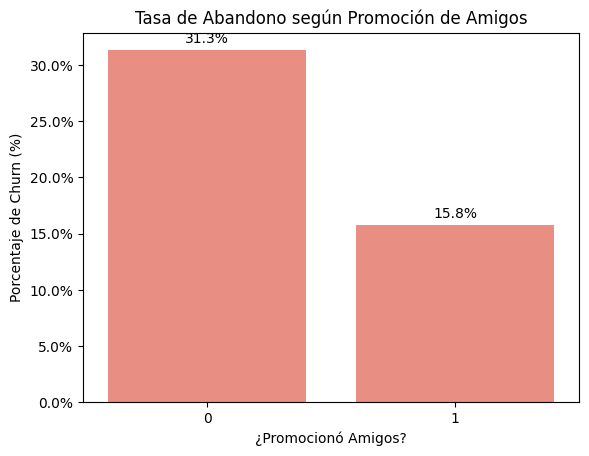

In [121]:
ax = sns.barplot(data = df2, x='Promo_friends', y='Churn', errorbar=None, color='salmon')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
etiquetas_barras = [f"{barra.get_height():.1%}" for barra in ax.containers[0]]
ax.bar_label(ax.containers[0], labels=etiquetas_barras, padding=3)
plt.title('Tasa de Abandono según Promoción de Amigos')
plt.ylabel('Porcentaje de Churn (%)')
plt.xlabel('¿Promocionó Amigos?')
plt.show()

El 31% de los que abandonaron el gimnasio no tenían la promoción de ser invitados por amigos.

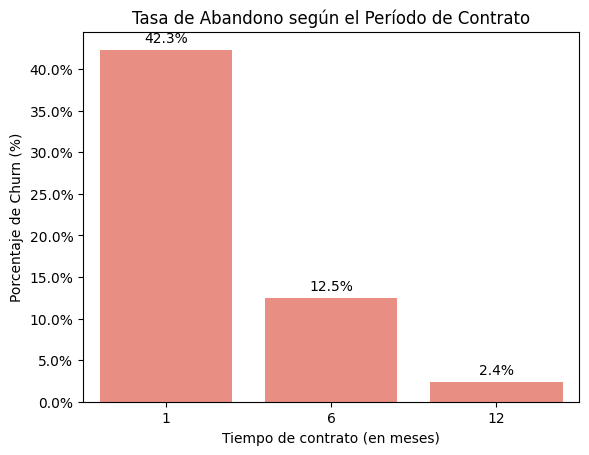

In [122]:
ax = sns.barplot(data = df2, x='Contract_period', y='Churn', errorbar=None, color='salmon')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
etiquetas_barras = [f"{barra.get_height():.1%}" for barra in ax.containers[0]]
ax.bar_label(ax.containers[0], labels=etiquetas_barras, padding=3)
plt.title('Tasa de Abandono según el Período de Contrato')
plt.ylabel('Porcentaje de Churn (%)')
plt.xlabel('Tiempo de contrato (en meses)')
plt.show()

Los clientes que más abandonan el servicio pagan el contrato mensual

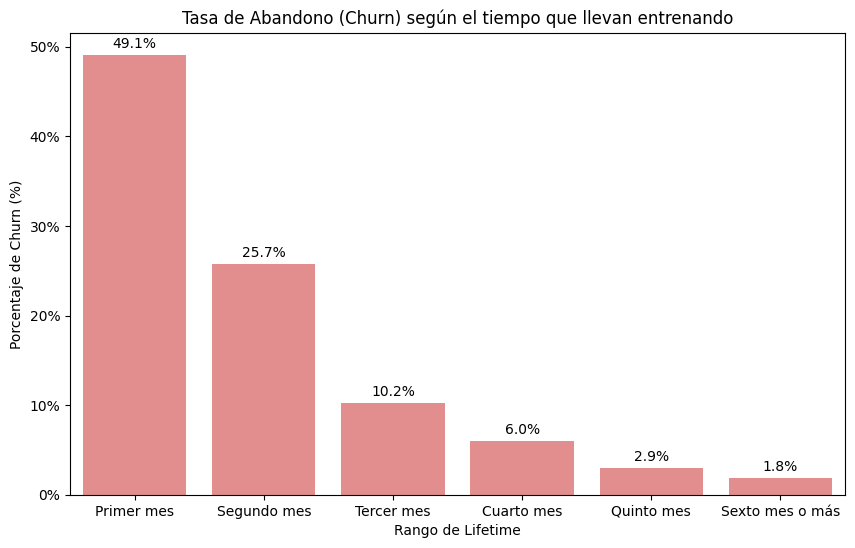

In [123]:
limites_lifetime = [0, 1, 2, 3, 4, 5, 6] 

nombres_intervalos = ['Primer mes', 'Segundo mes', 'Tercer mes', 'Cuarto mes', 'Quinto mes', 'Sexto mes o más']

df['Lifetime_group'] = pd.cut(df['Lifetime'], bins=limites_lifetime, labels=nombres_intervalos)

plt.figure(figsize=(10, 6)) 
ax = sns.barplot(data=df, x='Lifetime_group', y='Churn', errorbar=None, color='lightcoral') 

ax.yaxis.set_major_formatter(PercentFormatter(1.0))

etiquetas_barras = [f"{barra.get_height():.1%}" for barra in ax.containers[0]]
ax.bar_label(ax.containers[0], labels=etiquetas_barras, padding=3)

plt.title('Tasa de Abandono (Churn) según el tiempo que llevan entrenando')
plt.ylabel('Porcentaje de Churn (%)')
plt.xlabel('Rango de Lifetime')

plt.show()

In [124]:
scaler = StandardScaler()

In [125]:
model = LogisticRegression()

In [126]:
X = df2.drop(columns=['Churn', 'Age_group', 'Avg_class_frequency_total'])
X['caida_frecuencia'] = caida_frecuencia
y = df2['Churn']

In [127]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [128]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [129]:
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [130]:
model.score(X_test_scaled, y_test)

0.931

In [131]:
X.head()

,Near_Location,Partner,Promo_friends,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_current_month,caida_frecuencia
0,1,1,1,6,1,29,14.227470,5.0,3,0.000000,0.020398
1,1,0,0,12,1,31,113.202938,12.0,7,1.910244,0.012693
2,1,1,0,1,0,28,129.448479,1.0,2,1.736502,0.122596
3,1,1,1,12,1,33,62.669863,12.0,2,3.357215,-0.151582
4,1,1,1,1,0,26,198.362265,1.0,3,1.120078,-0.006194


In [154]:
cliente = {
    'Near_Location': 1,
    'Partner': 0,
    'Promo_friends': 1,
    'Contract_period': 12,
    'Group_visits': 0,
    'Age': 23,
    'Avg_additional_charges_total': 0,
    'Month_to_end_contract': 1,
    'Lifetime':20,
    'Avg_class_frequency_current_month': 4,
    'caida_frecuencia': 0.03
}

In [153]:
model.predict(scaler.transform(pd.DataFrame([cliente])))

array([0])